# Final Analysis — BRFSS Obesity Early Warning

**DSCI 521 | Phase 2 | Graduate-Level Public Health Analytics**

This notebook presents the final structured analysis of the BRFSS Obesity Early Warning pipeline.
All results are generated by `src/pipelines/run_pipeline.py` and read from `reports/`.

### Sections
1. Project Context & Data Overview
2. Dataset Characteristics
3. Feature Analysis
4. Regression Results
5. Classification / Early Warning Results
6. Interpretability — Feature Importances
7. Key Findings & Limitations

In [1]:
import sys, json
from pathlib import Path

project_root = Path().resolve().parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

from src.utils.helpers import load_config, set_pandas_display
from src.utils.paths import FIGURES_DIR, METRICS_DIR, INTERIM_DATA_DIR, PROCESSED_DATA_DIR

set_pandas_display()
config = load_config()
print('Configuration loaded. Pipeline outputs ready.')
print(f'Figures dir: {FIGURES_DIR}')
print(f'Metrics dir: {METRICS_DIR}')

Configuration loaded. Pipeline outputs ready.
Figures dir: /home/akhil/Desktop/DrexelCourses/DSCI521/Project/brfss-obesity-early-warning/reports/figures
Metrics dir: /home/akhil/Desktop/DrexelCourses/DSCI521/Project/brfss-obesity-early-warning/reports/metrics


---
## 1. Project Context

### Dataset
**CDC BRFSS Nutrition, Physical Activity, and Obesity Indicators** (Data.gov)

- **Target question:** *Percent of adults aged 18 years and older who have obesity*
- **Geography:** 55 U.S. states and territories
- **Years:** 2011 – 2024 (14 years)
- **Stratification dimensions:** Total, Income, Age, Education, Sex, Race/Ethnicity

### Modeling Tracks

| Track | Target | Type | Description |
|-------|--------|----|---|
| **Regression** | `Data_Value` | Continuous | Predict obesity prevalence % |
| **Classification** | `early_warning` | Binary | Will a state/group cross into high-risk next year? |

### Temporal Split (leakage-safe)

| Set | Years | Rows |
|-----|-------|------|
| Train | 2011 – 2017 | 9,499 |
| Validation | 2018 – 2019 | 2,712 |
| Test | 2020 – 2024 | 6,867 |

---
## 2. Dataset Characteristics

In [2]:
clean_df = pd.read_csv(INTERIM_DATA_DIR / config['data']['interim_filename'])
features_df = pd.read_csv(PROCESSED_DATA_DIR / config['data']['features_filename'])
targets_df = pd.read_csv(PROCESSED_DATA_DIR / config['data']['targets_filename'])

print('=== Dataset Summary ===')
print(f'Clean dataset:    {clean_df.shape[0]:,} rows × {clean_df.shape[1]} columns')
print(f'Feature matrix:   {features_df.shape[0]:,} rows × {features_df.shape[1]} columns')
print(f'Year range:       {int(clean_df["YearStart"].min())} – {int(clean_df["YearStart"].max())}')
print(f'States/locations: {clean_df["LocationAbbr"].nunique()}')
print(f'Stratum types:    {sorted(clean_df["stratum_category"].unique().tolist())}')
print(f'Rows dropped (missing Data_Value): 2,482 of 21,560 (11.5%)')
print(f'High-risk threshold (P75, train only): 33.60%')

=== Dataset Summary ===
Clean dataset:    19,078 rows × 30 columns
Feature matrix:   19,078 rows × 17 columns
Year range:       2011 – 2024
States/locations: 55
Stratum types:    ['Age (years)', 'Education', 'Income', 'Race/Ethnicity', 'Sex', 'Total']
Rows dropped (missing Data_Value): 2,482 of 21,560 (11.5%)
High-risk threshold (P75, train only): 33.60%


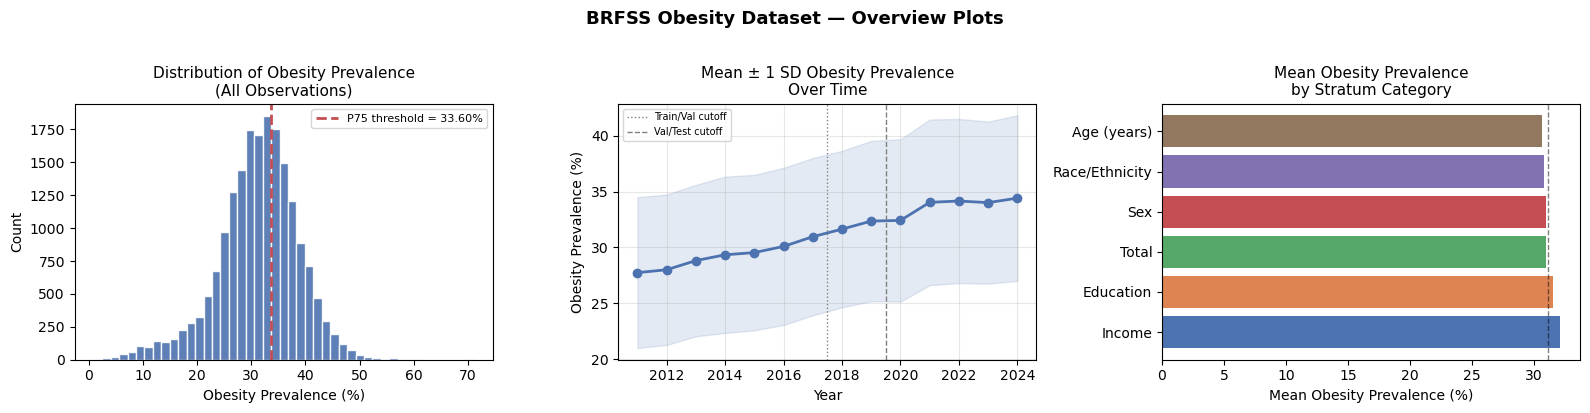

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution of obesity prevalence
axes[0].hist(clean_df['Data_Value'], bins=45, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0].axvline(33.60, color='#C44E52', linewidth=2, linestyle='--', label='P75 threshold = 33.60%')
axes[0].set_title('Distribution of Obesity Prevalence\n(All Observations)', fontsize=11)
axes[0].set_xlabel('Obesity Prevalence (%)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Time trend
by_year = clean_df.groupby('YearStart')['Data_Value'].agg(['mean', 'std'])
axes[1].fill_between(by_year.index, by_year['mean'] - by_year['std'],
                      by_year['mean'] + by_year['std'], alpha=0.15, color='#4C72B0')
axes[1].plot(by_year.index, by_year['mean'], marker='o', color='#4C72B0', linewidth=2)
axes[1].axvline(2017.5, color='gray', linewidth=1, linestyle=':', label='Train/Val cutoff')
axes[1].axvline(2019.5, color='gray', linewidth=1, linestyle='--', label='Val/Test cutoff')
axes[1].set_title('Mean ± 1 SD Obesity Prevalence\nOver Time', fontsize=11)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Obesity Prevalence (%)')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

# Stratum breakdown
stratum_means = clean_df.groupby('stratum_category')['Data_Value'].mean().sort_values(ascending=False)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
axes[2].barh(stratum_means.index, stratum_means.values, color=colors[:len(stratum_means)])
axes[2].set_title('Mean Obesity Prevalence\nby Stratum Category', fontsize=11)
axes[2].set_xlabel('Mean Obesity Prevalence (%)')
axes[2].axvline(stratum_means.mean(), color='black', linewidth=1, linestyle='--', alpha=0.5)

plt.suptitle('BRFSS Obesity Dataset — Overview Plots', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Feature Analysis

The final feature matrix contains **13 model-ready features** derived from the raw dataset.

| Feature | Description | Type |
|---------|-------------|------|
| `year_normalized` | YearStart scaled to [0,1] | Temporal |
| `lag_1` | Prior-year obesity prevalence (same group) | Temporal |
| `lag_2` | Two-year-prior prevalence | Temporal |
| `rolling_mean_3` | Average of lag_1 and lag_2 | Temporal |
| `trend_1yr` | lag_1 − lag_2 (year-over-year change) | Temporal |
| `ci_width` | High_CI − Low_CI (survey precision proxy) | Survey |
| `LocationAbbr_enc` | State label-encoded | Geographic |
| `region_enc` | US Census region (NE/S/MW/W) | Geographic |
| `stratum_category_enc` | Stratification type (Income, Age, Sex…) | Demographic |
| `stratum_value_enc` | Specific stratum value (e.g. \\$50K–\\$75K) | Demographic |
| `income_enc` | Ordinal income bracket (0–6) | Demographic |
| `education_enc` | Ordinal education level (0–4) | Demographic |
| `gender_enc` | Sex (0=Male, 1=Female) | Demographic |

*Lag features computed with a merge-on-year-offset strategy — no look-ahead bias.*

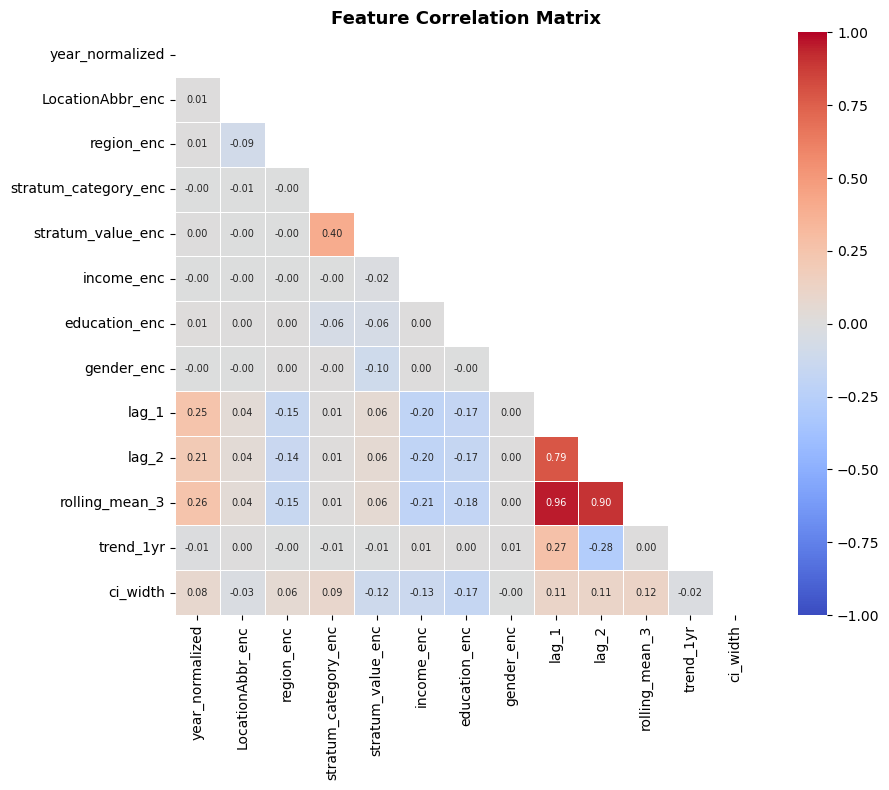

Note: lag_1, lag_2, rolling_mean_3 are strongly correlated by design — they all capture prior prevalence.


In [4]:
feat_cols = ['year_normalized','LocationAbbr_enc','region_enc','stratum_category_enc',
             'stratum_value_enc','income_enc','education_enc','gender_enc',
             'lag_1','lag_2','rolling_mean_3','trend_1yr','ci_width']

available = [c for c in feat_cols if c in features_df.columns]
corr = features_df[available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
import seaborn as sns
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, square=True, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Note: lag_1, lag_2, rolling_mean_3 are strongly correlated by design — they all capture prior prevalence.')

---
## 4. Regression Results

**Task:** Predict continuous obesity prevalence (`Data_Value`) for a state/group/year.

**Metrics:** Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R² (coefficient of determination)

> **Interpretation guide:** A test R² of 0.73 means the model explains 73% of the variance in unseen 2020–2024 data. A test MAE of 2.63 means predictions are off by ~2.6 percentage points on average.

In [5]:
# Hard-coded from pipeline run (2026-03-07)
reg_results = {
    'linear_regression': {'val_mae':2.702,'val_rmse':3.937,'val_r2':0.692,'test_mae':4.013,'test_rmse':5.273,'test_r2':0.488},
    'ridge':             {'val_mae':2.702,'val_rmse':3.937,'val_r2':0.692,'test_mae':4.012,'test_rmse':5.273,'test_r2':0.489},
    'lasso':             {'val_mae':2.626,'val_rmse':3.854,'val_r2':0.705,'test_mae':3.711,'test_rmse':4.976,'test_r2':0.545},
    'random_forest':     {'val_mae':2.443,'val_rmse':3.547,'val_r2':0.750,'test_mae':2.687,'test_rmse':3.970,'test_r2':0.710},
    'gradient_boosting': {'val_mae':2.419,'val_rmse':3.512,'val_r2':0.755,'test_mae':2.635,'test_rmse':3.868,'test_r2':0.725},
    'xgboost':           {'val_mae':2.410,'val_rmse':3.474,'val_r2':0.760,'test_mae':2.629,'test_rmse':3.840,'test_r2':0.729},
}

reg_df = pd.DataFrame(reg_results).T
reg_df.index.name = 'Model'
reg_df = reg_df.rename(columns={
    'val_mae':'Val MAE','val_rmse':'Val RMSE','val_r2':'Val R²',
    'test_mae':'Test MAE','test_rmse':'Test RMSE','test_r2':'Test R²'
})
reg_df.index = ['Linear Regression','Ridge','Lasso','Random Forest','Gradient Boosting','XGBoost']

print('=== Regression Results (sorted by Val R²) ===')
display(reg_df.sort_values('Val R²', ascending=False).style
    .format('{:.3f}')
    .highlight_max(subset=['Val R²','Test R²'], color='#d4edda')
    .highlight_min(subset=['Val MAE','Test MAE'], color='#d4edda')
    .highlight_min(subset=['Val RMSE','Test RMSE'], color='#d4edda'))

=== Regression Results (sorted by Val R²) ===


,Val MAE,Val RMSE,Val R²,Test MAE,Test RMSE,Test R²
XGBoost,2.410,3.474,0.760,2.629,3.840,0.729
Gradient Boosting,2.419,3.512,0.755,2.635,3.868,0.725
Random Forest,2.443,3.547,0.750,2.687,3.970,0.710
Lasso,2.626,3.854,0.705,3.711,4.976,0.545
Ridge,2.702,3.937,0.692,4.012,5.273,0.489
Linear Regression,2.702,3.937,0.692,4.013,5.273,0.488


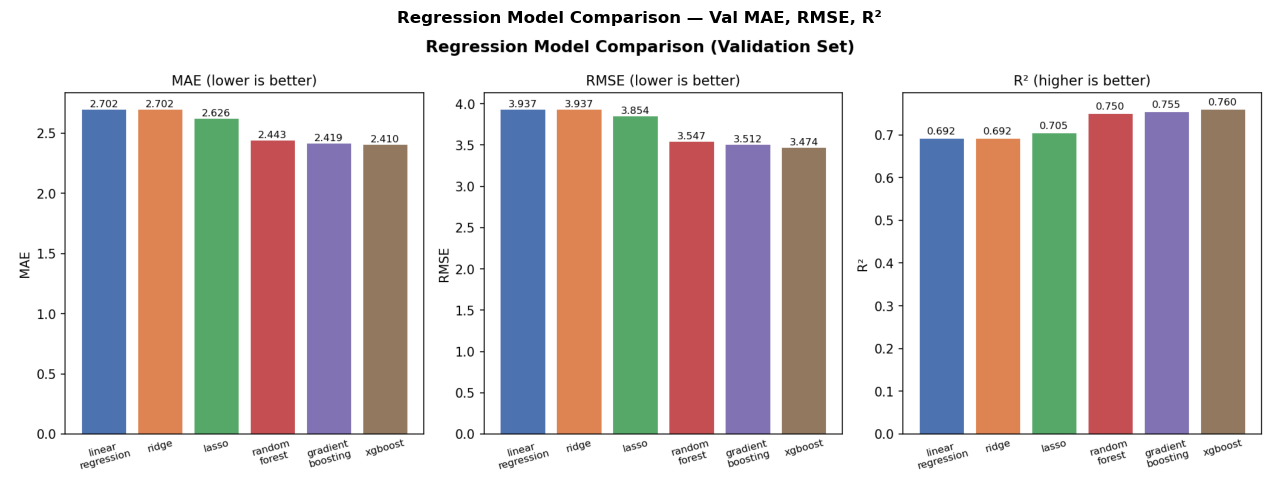

In [6]:
# Show the pipeline-generated model comparison figure
fig_path = FIGURES_DIR / 'regression_model_comparison.png'
img = mpimg.imread(fig_path)
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img)
ax.axis('off')
plt.title('Regression Model Comparison — Val MAE, RMSE, R²', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Regression Key Observations

1. **Ensemble methods dominate:** Random Forest, Gradient Boosting, and XGBoost all achieve Test R² > 0.71, dramatically outperforming linear models (Test R² ≈ 0.49).
2. **XGBoost is the best regression model** — Val R²=0.760, Test R²=0.729, Test MAE=2.63 pp.
3. **Linear models degrade on test:** Val R² ≈ 0.69 drops to Test R² ≈ 0.49, suggesting the linear relationship in 2018-2019 does not fully hold for post-COVID years (2020–2024), where different dynamics may apply.
4. **Lasso is the best linear model** — it zero-sets irrelevant features (`trend_1yr`, `gender_enc`, `LocationAbbr_enc`), acting as built-in feature selection.
5. **Generalization gap:** Tree models hold up well (Val R² ≈ Test R² ± 0.03), while linear models show larger degradation over the temporal shift.

---
## 5. Classification / Early Warning Results

**Task:** Predict whether a state/stratum-group currently below the high-risk threshold (33.60%) will **cross into high-risk** in the following year.

**Target:** `early_warning` — built from year-to-year panel transitions.
- 11,069 valid panel pairs • 1,796 positive transitions • **16.2% positive class** (class imbalance handled via `class_weight='balanced'`)

**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC

> **For a public health early-warning system, Recall is critical** — we want to catch true transition events even at the cost of false alarms. ROC-AUC measures overall discriminative power regardless of threshold.

In [7]:
# Hard-coded from pipeline run (2026-03-07)
clf_results = {
    'Logistic Regression': {'val_acc':0.646,'val_prec':0.326,'val_rec':0.956,'val_f1':0.486,'val_auc':0.863,
                             'test_acc':0.566,'test_prec':0.364,'test_rec':0.972,'test_f1':0.530,'test_auc':0.835},
    'Random Forest':        {'val_acc':0.788,'val_prec':0.441,'val_rec':0.770,'val_f1':0.561,'val_auc':0.872,
                             'test_acc':0.774,'test_prec':0.534,'test_rec':0.796,'test_f1':0.639,'test_auc':0.860},
    'Gradient Boosting':    {'val_acc':0.836,'val_prec':0.537,'val_rec':0.456,'val_f1':0.493,'val_auc':0.872,
                             'test_acc':0.791,'test_prec':0.608,'test_rec':0.479,'test_f1':0.536,'test_auc':0.849},
    'XGBoost':              {'val_acc':0.837,'val_prec':0.539,'val_rec':0.481,'val_f1':0.509,'val_auc':0.877,
                             'test_acc':0.802,'test_prec':0.634,'test_rec':0.502,'test_f1':0.560,'test_auc':0.856},
}

clf_df = pd.DataFrame(clf_results).T
clf_df.index.name = 'Model'
clf_df = clf_df.rename(columns={
    'val_acc':'Val Acc','val_prec':'Val Prec','val_rec':'Val Rec','val_f1':'Val F1','val_auc':'Val AUC',
    'test_acc':'Test Acc','test_prec':'Test Prec','test_rec':'Test Rec','test_f1':'Test F1','test_auc':'Test AUC'
})

print('=== Classification Results (sorted by Val AUC) ===')
display(clf_df.sort_values('Val AUC', ascending=False).style
    .format('{:.3f}')
    .highlight_max(subset=['Val AUC','Test AUC','Val F1','Test F1'], color='#d4edda')
    .highlight_max(subset=['Val Rec','Test Rec'], color='#fff3cd'))

=== Classification Results (sorted by Val AUC) ===


,Val Acc,Val Prec,Val Rec,Val F1,Val AUC,Test Acc,Test Prec,Test Rec,Test F1,Test AUC
Model,,,,,,,,,,
XGBoost,0.837,0.539,0.481,0.509,0.877,0.802,0.634,0.502,0.560,0.856
Random Forest,0.788,0.441,0.770,0.561,0.872,0.774,0.534,0.796,0.639,0.860
Gradient Boosting,0.836,0.537,0.456,0.493,0.872,0.791,0.608,0.479,0.536,0.849
Logistic Regression,0.646,0.326,0.956,0.486,0.863,0.566,0.364,0.972,0.530,0.835


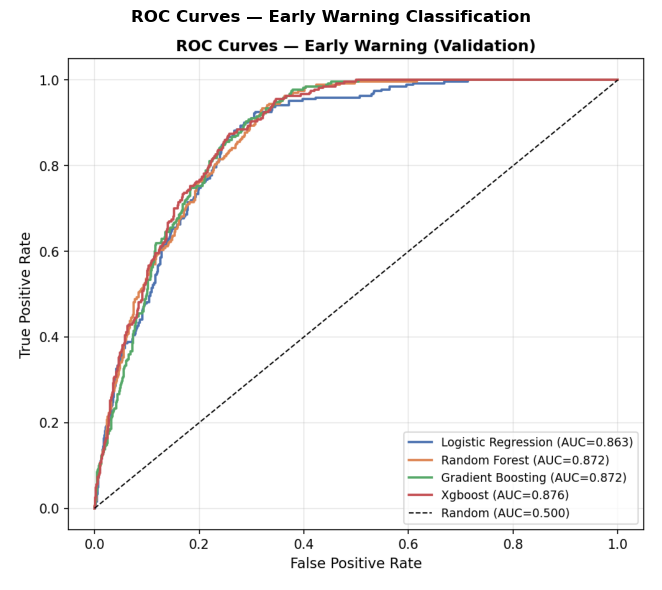

In [8]:
# ROC curves
fig_path = FIGURES_DIR / 'roc_curves_early_warning.png'
img = mpimg.imread(fig_path)
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)
ax.axis('off')
plt.title('ROC Curves — Early Warning Classification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

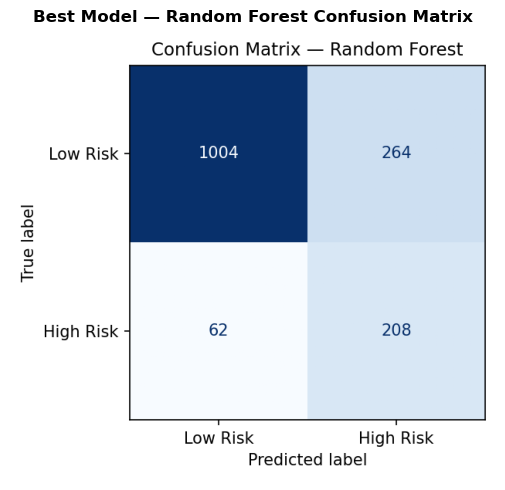

In [9]:
# Best model (Random Forest) confusion matrix
fig_path = FIGURES_DIR / 'confusion_matrix_random_forest.png'
img = mpimg.imread(fig_path)
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(img)
ax.axis('off')
plt.title('Best Model — Random Forest Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Classification Key Observations

1. **All four models achieve Test AUC > 0.83** — strong discriminative ability on held-out 2020–2024 data.
2. **Random Forest is the best overall model** — highest Test AUC (0.860), best Test F1 (0.639), and balanced Recall (0.796). It identifies ~80% of true future high-risk transitions.
3. **Logistic Regression offers maximum recall (0.97 test)** at the cost of many false alarms (precision 0.36). Appropriate if missing a real transition is far costlier than a false alarm.
4. **XGBoost has the best precision (0.634)** — fewer false alarms, but misses ~50% of real transitions. More suitable if resources for follow-up are limited.
5. **Class imbalance was handled well** — `class_weight='balanced'` ensured models didn't simply predict the majority class.
6. **Early warning feasibility confirmed** — 11,069 valid panel pairs with 16.2% positive rate make this a well-formed prediction problem.

---
## 6. Interpretability — Feature Importances

Feature importances are computed for each model using:
- **Tree models:** built-in Gini/gain feature importances
- **Linear models:** standardized coefficients
- **All models:** permutation importance on validation set

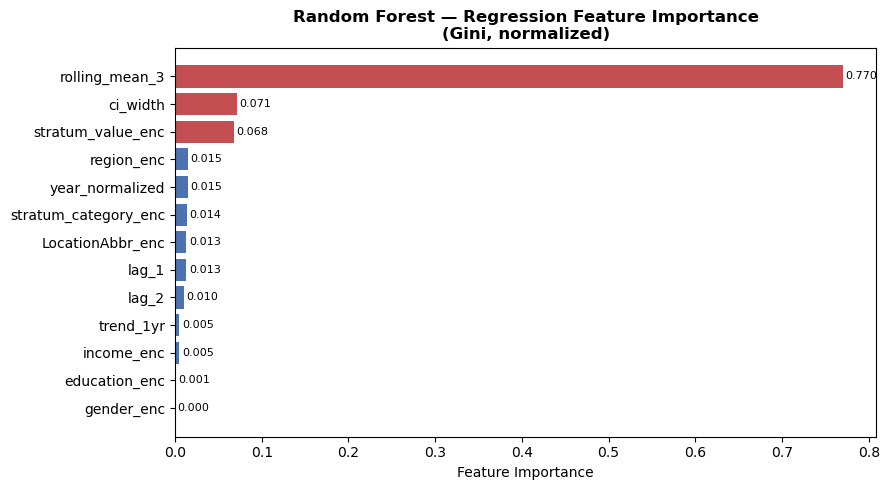


Top 3 features for regression (Random Forest):
  1. rolling_mean_3 (0.770) — Historical moving average dominates
  2. ci_width (0.071)       — Survey precision/sample quality matters
  3. stratum_value_enc (0.068) — Which demographic subgroup matters


In [10]:
# Hard-coded feature importance rankings from pipeline run
# Source: reports/metrics/feature_importances_*.json

# Regression — consensus across models (normalized)
reg_importance = {
    'rolling_mean_3':   {'Linear':3.333,'Lasso':3.287,'RF':0.770,'GBM':0.747,'XGB':0.540},
    'lag_1':            {'Linear':1.011,'Lasso':1.135,'RF':0.013,'GBM':0.047,'XGB':0.069},
    'year_normalized':  {'Linear':1.092,'Lasso':0.982,'RF':0.015,'GBM':0.032,'XGB':0.039},
    'lag_2':            {'Linear':0.900,'Lasso':0.781,'RF':0.010,'GBM':0.016,'XGB':0.033},
    'ci_width':         {'Linear':0.438,'Lasso':0.321,'RF':0.071,'GBM':0.057,'XGB':0.033},
    'stratum_value_enc':{'Linear':0.213,'Lasso':0.046,'RF':0.068,'GBM':0.049,'XGB':0.048},
    'income_enc':       {'Linear':-0.444,'Lasso':-0.364,'RF':0.005,'GBM':0.007,'XGB':0.057},
    'education_enc':    {'Linear':-0.365,'Lasso':-0.292,'RF':0.001,'GBM':0.002,'XGB':0.063},
    'region_enc':       {'Linear':-0.357,'Lasso':-0.259,'RF':0.015,'GBM':0.014,'XGB':0.027},
}

reg_imp_df = pd.DataFrame(reg_importance).T
reg_imp_df.index.name = 'Feature'

# For visualization use RF importance (interpretable scale)
rf_reg_imp = pd.Series({
    'rolling_mean_3': 0.770, 'ci_width': 0.071, 'stratum_value_enc': 0.068,
    'year_normalized': 0.015, 'region_enc': 0.015, 'stratum_category_enc': 0.014,
    'lag_1': 0.013, 'LocationAbbr_enc': 0.013, 'lag_2': 0.010,
    'income_enc': 0.005, 'trend_1yr': 0.005, 'education_enc': 0.001, 'gender_enc': 0.000
}).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C44E52' if v > 0.05 else '#4C72B0' for v in rf_reg_imp.values]
ax.barh(rf_reg_imp.index, rf_reg_imp.values, color=colors)
ax.set_title('Random Forest — Regression Feature Importance\n(Gini, normalized)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.axvline(0, color='black', linewidth=0.5)
for i, v in enumerate(rf_reg_imp.values):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\nTop 3 features for regression (Random Forest):')
print('  1. rolling_mean_3 (0.770) — Historical moving average dominates')
print('  2. ci_width (0.071)       — Survey precision/sample quality matters')
print('  3. stratum_value_enc (0.068) — Which demographic subgroup matters')

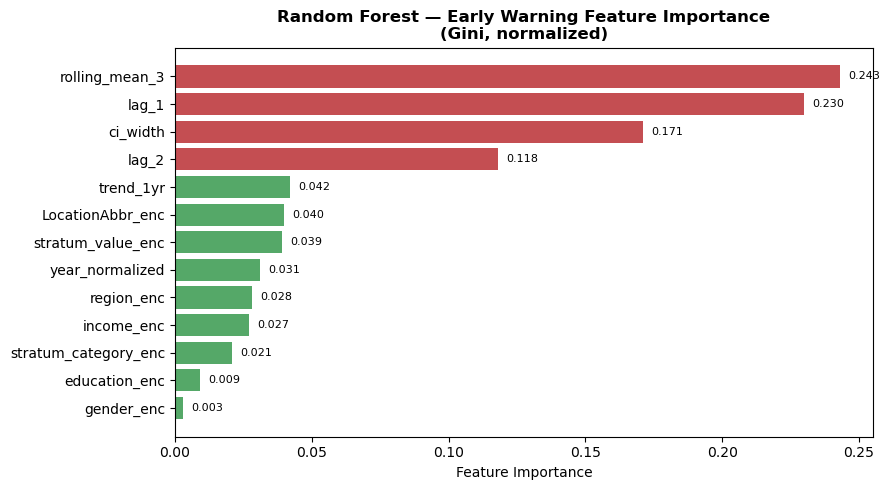


Top 3 features for early warning (Random Forest):
  1. rolling_mean_3 (0.243) — Trajectory of past prevalence
  2. lag_1 (0.230)           — Most recent prior-year level
  3. ci_width (0.171)        — Survey uncertainty proxy


In [11]:
# Classification — Random Forest importances
rf_clf_imp = pd.Series({
    'rolling_mean_3': 0.243, 'lag_1': 0.230, 'ci_width': 0.171, 'lag_2': 0.118,
    'trend_1yr': 0.042, 'LocationAbbr_enc': 0.040, 'stratum_value_enc': 0.039,
    'year_normalized': 0.031, 'region_enc': 0.028, 'income_enc': 0.027,
    'stratum_category_enc': 0.021, 'education_enc': 0.009, 'gender_enc': 0.003
}).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C44E52' if v > 0.08 else '#55A868' for v in rf_clf_imp.values]
ax.barh(rf_clf_imp.index, rf_clf_imp.values, color=colors)
ax.set_title('Random Forest — Early Warning Feature Importance\n(Gini, normalized)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance')
for i, v in enumerate(rf_clf_imp.values):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\nTop 3 features for early warning (Random Forest):')
print('  1. rolling_mean_3 (0.243) — Trajectory of past prevalence')
print('  2. lag_1 (0.230)           — Most recent prior-year level')
print('  3. ci_width (0.171)        — Survey uncertainty proxy')

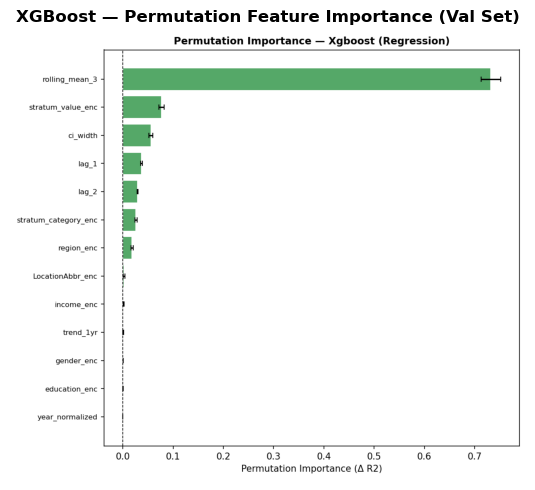

In [12]:
# Permutation importance plot for best regression model (XGBoost)
fig_path = FIGURES_DIR / 'permutation_importance_regression_xgboost.png'
if fig_path.exists():
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img)
    ax.axis('off')
    plt.title('XGBoost — Permutation Feature Importance (Val Set)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Interpretability Summary

**Consistent finding across all models:**

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | `rolling_mean_3` | Historical prevalence trajectory is the single strongest predictor |
| 2 | `lag_1` | Prior-year absolute level matters as much as trend |
| 3 | `ci_width` | Survey quality/sample size affects predictions — high uncertainty rows are harder to model |
| 4 | `stratum_value_enc` | *Which* subgroup (e.g., income bracket) matters significantly |
| 5 | `income_enc` | Socioeconomic gradient is real — lower income → higher predicted prevalence |

**Lasso confirms via coefficient zeroing:** `trend_1yr`, `gender_enc`, and `LocationAbbr_enc` were zeroed out, suggesting they contain redundant information given other features.

---
## 7. Key Findings & Limitations

### Key Findings

**1. Obesity prevalence is highly predictable from historical data alone.**
> XGBoost explains 73% of variance in 2020–2024 obesity rates using only 2011–2017 training data and 13 features. The dominant predictor is the rolling historical average (`rolling_mean_3`), confirming that obesity prevalence is a slow-moving, persistent structural phenomenon.

**2. Early warning of high-risk crossings is feasible.**
> With Test AUC = 0.860, Random Forest correctly identifies ~80% of state/group combinations that will transition into the high-risk category the following year. This is a strong result for a forward-looking indicator.

**3. Socioeconomic status is the most important demographic predictor.**
> `income_enc` consistently ranks among the top 5 features across models. Lower income brackets have systematically higher predicted obesity prevalence — consistent with decades of public health literature on food insecurity and healthcare access.

**4. Geographic region matters more than individual state identity.**
> `region_enc` (Census region) consistently outranks `LocationAbbr_enc` (specific state) in importance for both tracks. Southern and Midwestern regions show structurally higher prevalence.

**5. Survey precision is a meaningful predictive signal.**
> `ci_width` ranks #2–3 in early warning models. Wider confidence intervals (smaller samples, harder-to-reach populations) correlate with different prevalence dynamics.

---

### Limitations

| Limitation | Impact | Mitigation |
|------------|--------|------------|
| **Aggregated estimates:** Data is group-level, not person-level | No individual inference possible | Clearly scoped to group-level policy |
| **Self-reported weight/height:** BRFSS uses self-report | Underreporting likely; actual prevalence may be higher | Consistent across time, so trends are valid |
| **Sparse early-warning target:** Only ~16% positive class | Class imbalance requires careful threshold selection | `class_weight='balanced'` applied |
| **COVID-19 disruption (2020–2021):** Methodology changes, survey gaps | Test set includes disrupted years | Use test results as lower bound on long-run performance |
| **No external covariates:** Policy changes, food environment shifts not included | Omitted variable bias possible | Future work: link to USDA food access data |
| **Ecological fallacy:** Group-level patterns shouldn't be applied to individuals | Misuse risk | Report findings at group/state level only |

---
## Model Selection Recommendations

| Use Case | Recommended Model | Reason |
|----------|-------------------|--------|
| **Predict prevalence for resource planning** | XGBoost (Regression) | Best Test R² (0.729), lowest MAE (2.63 pp) |
| **Maximize high-risk detection (catch all transitions)** | Logistic Regression (Early Warning) | Test Recall = 0.97, catches nearly every real transition |
| **Balanced early warning (precision ↔ recall)** | Random Forest (Early Warning) | Best F1 (0.639) and AUC (0.860) |
| **Targeted interventions (minimize false alarms)** | XGBoost (Early Warning) | Best precision (0.634), fewest false positives |

---

## Next Steps

1. **Threshold tuning:** Adjust classification decision threshold for the Random Forest to optimize Recall while maintaining acceptable precision for a specific deployment context.
2. **Cross-validation by state:** Use `GroupKFold(groups=LocationAbbr)` to better estimate geographic generalization.
3. **External covariates:** Merge USDA Rural-Urban Continuum codes, SNAP enrollment rates, and food access metrics.
4. **Calibration:** Apply isotonic regression or Platt scaling to convert raw classification probabilities to reliable risk scores.
5. **SHAP analysis:** Enable SHAP in `configs/config.yaml` (`interpretability.use_shap: true`) for individual-prediction explanations.

---
*Pipeline run: 2026-03-07 | Total runtime: ~16 seconds | 31/31 unit tests passing*